# Stock Market Price Forecasting

## Objective

The objective of this project is to analyze historical stock market data and build a forecasting model to predict future closing prices.

## Business Objective

The model will help stakeholders and investors estimate future stock closing prices based on historical market behavior.

In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import Ridge

print("Libraries imported successfully")

Libraries imported successfully


In [93]:
df =pd.read_csv("HistoricalQuotes.csv")

In [94]:
df.head()

,date,close,volume,open,high,low
0,10-08-2019,200.99,24619446,201.23,202.760,199.29
1,09-08-2019,200.99,24619750,201.30,202.760,199.29
2,08-08-2019,203.43,27009520,200.20,203.530,199.39
3,07-08-2019,199.04,33364400,195.41,199.560,193.82
4,06-08-2019,197.00,35824790,196.31,198.067,194.04


In [95]:
df.shape

(253, 6)

In [96]:
df.columns

Index(['date', 'close', 'volume', 'open', 'high', 'low'], dtype='object')

In [97]:
df.dtypes

date       object
close     float64
volume      int64
open      float64
high      float64
low       float64
dtype: object

In [98]:
df.isnull().sum()

date      0
close     0
volume    0
open      0
high      0
low       0
dtype: int64

In [99]:
df.duplicated().sum()

np.int64(0)

In [100]:
df.describe()

,close,volume,open,high,low
count,253.000000,2.530000e+02,253.000000,253.000000,253.000000
mean,193.091858,3.248149e+07,193.031711,195.073753,191.073962
std,21.750344,1.370032e+07,21.772060,21.914049,21.700140
min,142.190000,1.136205e+07,143.980000,145.720000,142.000000
25%,174.870000,2.317102e+07,174.940000,176.000000,173.940000
50%,197.000000,2.961619e+07,196.450000,199.260000,194.040000
75%,208.880000,3.876370e+07,209.220000,210.640000,207.290000
max,232.070000,9.558408e+07,230.780000,233.470000,229.780000


In [101]:
df["date"]=pd.to_datetime(
    df["date"],
    dayfirst=True,
    errors="coerce"
)

In [102]:
df.dtypes

date      datetime64[ns]
close            float64
volume             int64
open             float64
high             float64
low              float64
dtype: object

In [103]:
df["date"].isnull().sum()

np.int64(0)

In [104]:
df=df.sort_values("date")

In [105]:
df.head()

,date,close,volume,open,high,low
252,2018-08-09,208.88,23389530,207.280,209.780,207.20
251,2018-08-10,207.53,24592460,207.360,209.100,206.67
250,2018-08-13,208.87,25864510,207.700,210.952,207.70
249,2018-08-14,209.75,20679270,210.155,210.560,208.26
248,2018-08-15,210.24,28595230,209.220,210.740,208.33


In [106]:
df=df.set_index("date")

In [107]:
df.head()

,close,volume,open,high,low
date,,,,,
2018-08-09,208.88,23389530,207.280,209.780,207.20
2018-08-10,207.53,24592460,207.360,209.100,206.67
2018-08-13,208.87,25864510,207.700,210.952,207.70
2018-08-14,209.75,20679270,210.155,210.560,208.26
2018-08-15,210.24,28595230,209.220,210.740,208.33


In [108]:
print("Start date:",df.index.min())
print("End date:",df.index.max())

Start date: 2018-08-09 00:00:00
End date: 2019-08-10 00:00:00


## Weekends/ non trading days

In [109]:
date_gaps=df.index.to_series().diff().dt.days
date_gaps.value_counts().sort_index()

date
1.0    195
2.0      5
3.0     47
4.0      5
Name: count, dtype: int64

In [110]:
weekend_data=df[df.index.dayofweek>=5]
weekend_data

,close,volume,open,high,low
date,,,,,
2019-08-10,200.99,24619446,201.23,202.76,199.29


In [111]:
df_clean=df[df.index.dayofweek<5].copy()

In [112]:
df_clean.head()

,close,volume,open,high,low
date,,,,,
2018-08-09,208.88,23389530,207.280,209.780,207.20
2018-08-10,207.53,24592460,207.360,209.100,206.67
2018-08-13,208.87,25864510,207.700,210.952,207.70
2018-08-14,209.75,20679270,210.155,210.560,208.26
2018-08-15,210.24,28595230,209.220,210.740,208.33


In [113]:
len(df),len(df_clean)

(253, 252)

In [114]:
df_clean.tail()

,close,volume,open,high,low
date,,,,,
2019-08-05,193.34,52392970,197.99,198.649,192.58
2019-08-06,197.00,35824790,196.31,198.067,194.04
2019-08-07,199.04,33364400,195.41,199.560,193.82
2019-08-08,203.43,27009520,200.20,203.530,199.39
2019-08-09,200.99,24619750,201.30,202.760,199.29


In [115]:
print("Number of obervations:",len(df_clean))

Number of obervations: 252


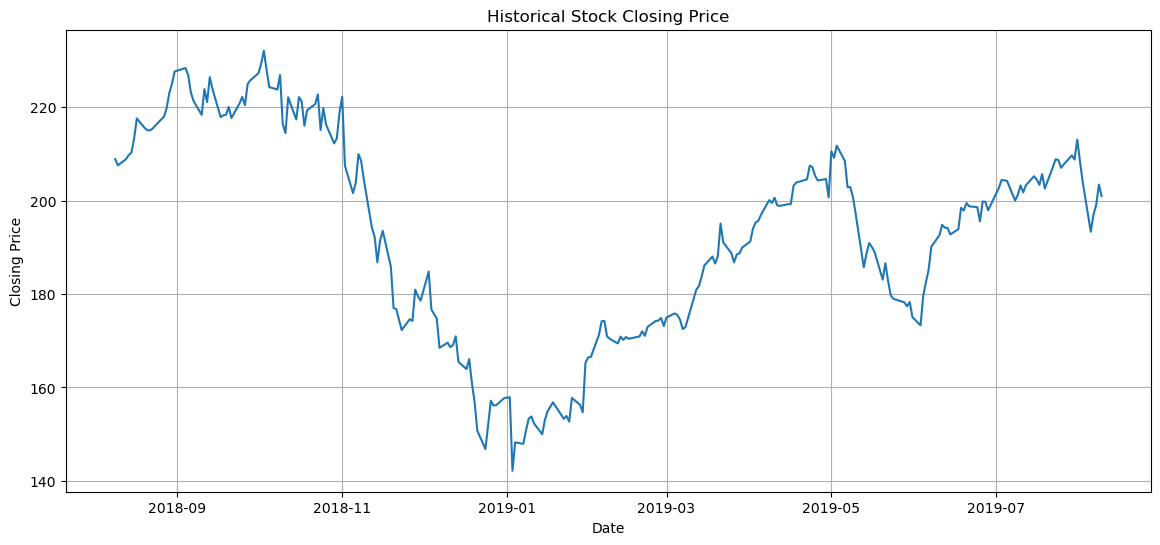

In [116]:
plt.figure(figsize=(14,6))
plt.plot(df_clean.index,df_clean["close"])
plt.title("Historical Stock Closing Price")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.grid(True)
plt.show()

In [117]:
date_gaps=df_clean.index.to_series().diff().dt.days
date_gaps.value_counts().sort_index()

date
1.0    194
2.0      5
3.0     47
4.0      5
Name: count, dtype: int64

In [118]:
date_gaps.mode()

0    1.0
Name: date, dtype: float64

In [119]:
# Identify missing business days
all_weekdays = pd.date_range(
    df.index.min(),
    df.index.max(),
    freq="B"
)

missing_weekdays = all_weekdays.difference(df.index)

print("Number of business days absent from the source:", len(missing_weekdays))
print("Missing business days:")
print(missing_weekdays.tolist())


Number of business days absent from the source: 10
Missing business days:
[Timestamp('2018-09-03 00:00:00'), Timestamp('2018-11-22 00:00:00'), Timestamp('2018-12-05 00:00:00'), Timestamp('2018-12-25 00:00:00'), Timestamp('2019-01-01 00:00:00'), Timestamp('2019-01-21 00:00:00'), Timestamp('2019-02-18 00:00:00'), Timestamp('2019-04-19 00:00:00'), Timestamp('2019-05-27 00:00:00'), Timestamp('2019-07-04 00:00:00')]


## Weekly plotting

In [120]:
weekly_close=df_clean["close"].resample("W-FRI").last()

In [121]:
weekly_close.head(10)

date
2018-08-10    207.53
2018-08-17    217.58
2018-08-24    216.16
2018-08-31    227.63
2018-09-07    221.30
2018-09-14    223.84
2018-09-21    217.66
2018-09-28    225.74
2018-10-05    224.29
2018-10-12    222.11
Freq: W-FRI, Name: close, dtype: float64

In [122]:
len(df_clean), len(weekly_close)

(252, 53)

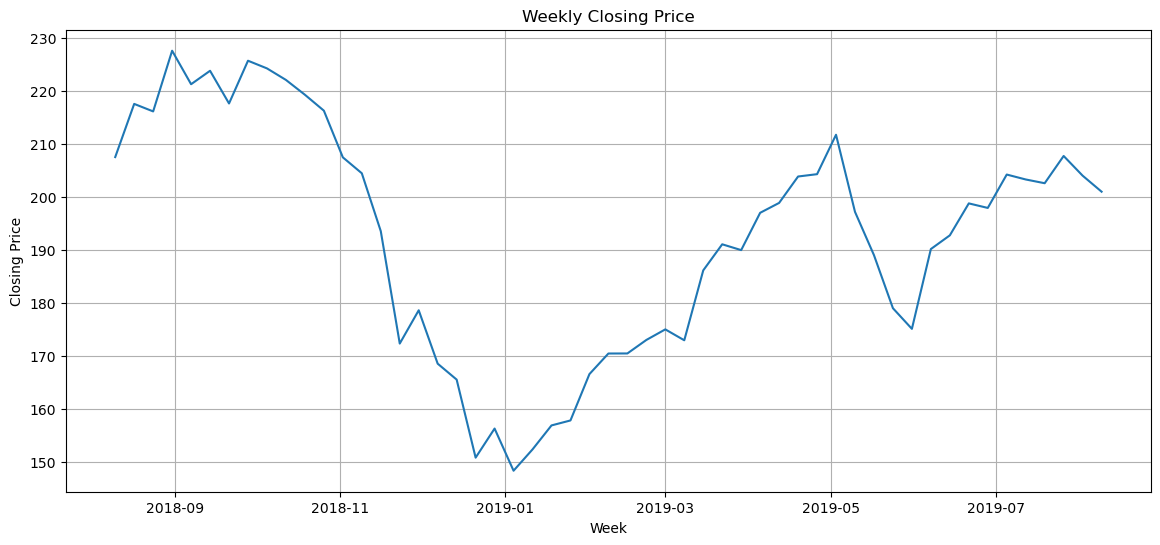

In [123]:
plt.figure(figsize=(14, 6))
plt.plot(weekly_close.index, weekly_close)
plt.title("Weekly Closing Price")
plt.xlabel("Week")
plt.ylabel("Closing Price")
plt.grid(True)
plt.show()

## Statistics

In [124]:
print("Minimum closing price:", df_clean["close"].min())
print("Maximum closing price:", df_clean["close"].max())
print("Average closing price:", df_clean["close"].mean())
print("Median closing price:", df_clean["close"].median())

Minimum closing price: 142.19
Maximum closing price: 232.07
Average closing price: 193.06051587301587
Median closing price: 197.0


In [125]:
df_clean["return"] = df_clean["close"].pct_change()
df_clean[["close", "return"]].head(10)

,close,return
date,,
2018-08-09,208.88,NaN
2018-08-10,207.53,-0.006463
2018-08-13,208.87,0.006457
2018-08-14,209.75,0.004213
2018-08-15,210.24,0.002336
2018-08-16,213.32,0.014650
2018-08-17,217.58,0.019970
2018-08-20,215.46,-0.009744
2018-08-21,215.04,-0.001949


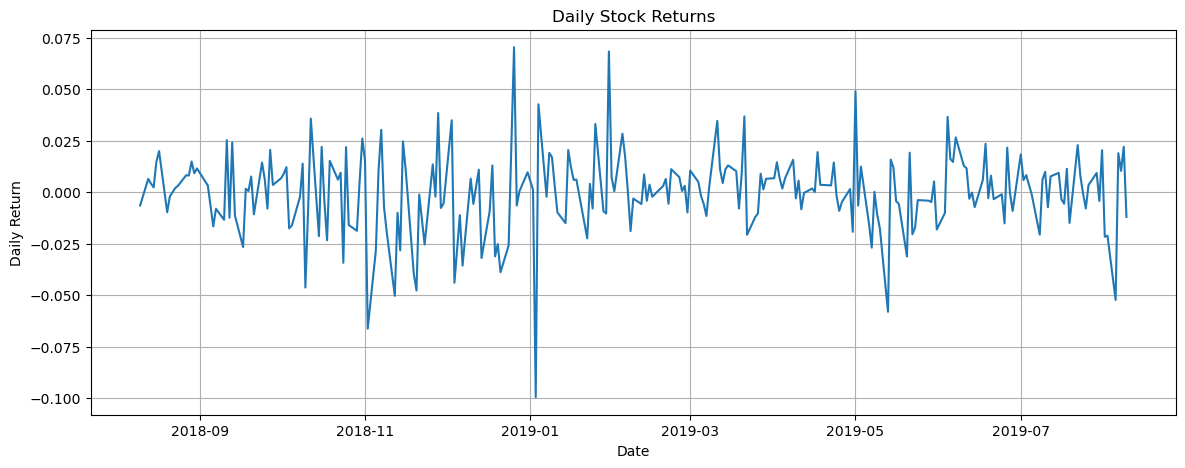

In [126]:
plt.figure(figsize=(14, 5))
plt.plot(df_clean.index, df_clean["return"])
plt.title("Daily Stock Returns")
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.grid(True)
plt.show()

In [127]:
df_clean["return"].describe()

count    251.000000
mean       0.000042
std        0.019708
min       -0.099607
25%       -0.009183
50%        0.001517
75%        0.010877
max        0.070422
Name: return, dtype: float64

## Time series decomposition

In [128]:
close_series=df_clean["close"].asfreq("B")

In [129]:
close_series.head(10)

date
2018-08-09    208.88
2018-08-10    207.53
2018-08-13    208.87
2018-08-14    209.75
2018-08-15    210.24
2018-08-16    213.32
2018-08-17    217.58
2018-08-20    215.46
2018-08-21    215.04
2018-08-22    215.05
Freq: B, Name: close, dtype: float64

In [130]:
close_for_decomp = close_series.interpolate(method="time")
close_for_decomp.head(10)

date
2018-08-09    208.88
2018-08-10    207.53
2018-08-13    208.87
2018-08-14    209.75
2018-08-15    210.24
2018-08-16    213.32
2018-08-17    217.58
2018-08-20    215.46
2018-08-21    215.04
2018-08-22    215.05
Freq: B, Name: close, dtype: float64

In [131]:
decomposition = seasonal_decompose(
    close_for_decomp,
    model="additive",
    period=5
)

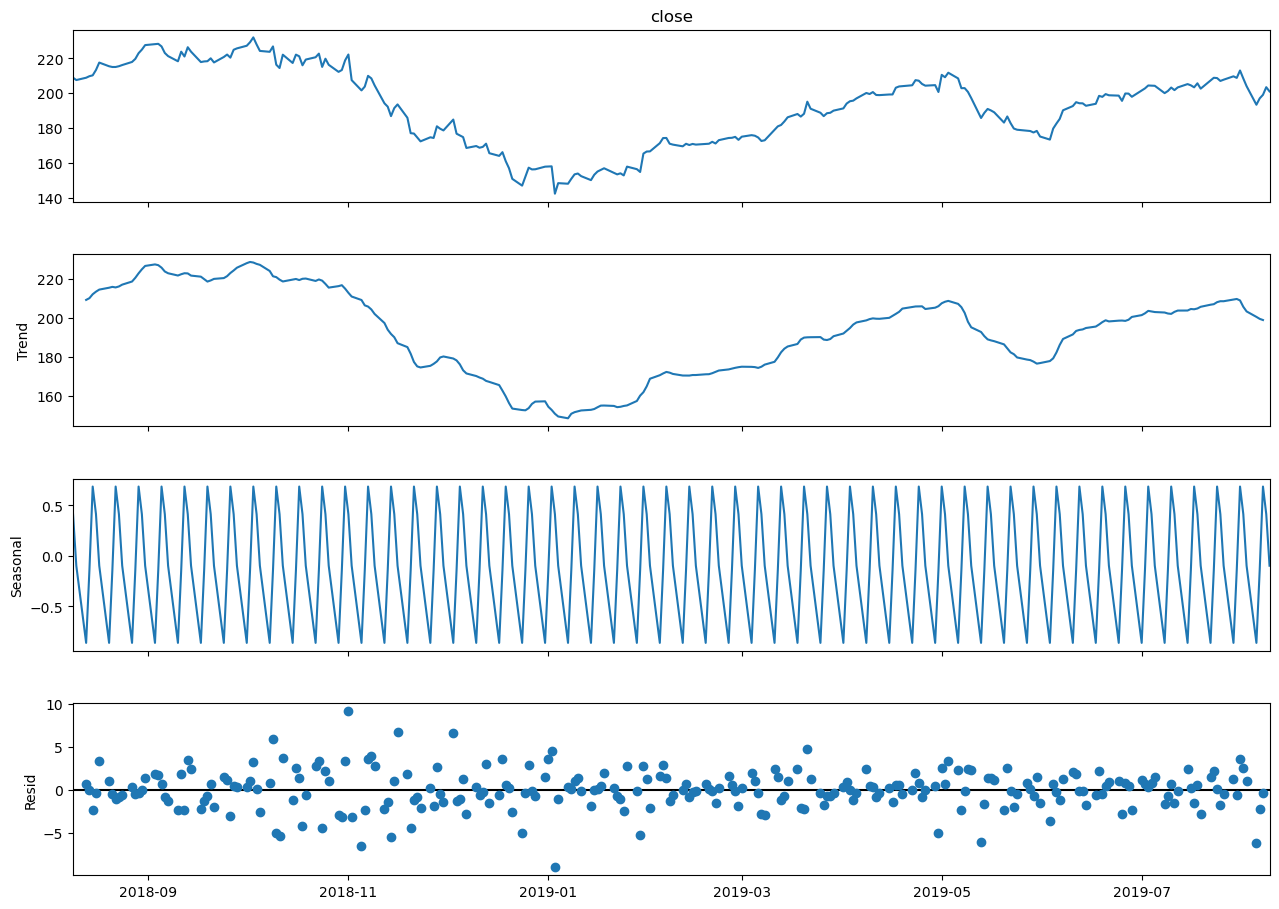

In [132]:
fig = decomposition.plot()
fig.set_size_inches(14, 10)
plt.show()

In [133]:
trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

In [134]:
trend.head()

date
2018-08-09        NaN
2018-08-10        NaN
2018-08-13    209.054
2018-08-14    209.942
2018-08-15    211.952
Freq: B, Name: trend, dtype: float64

In [135]:
seasonal.head()

date
2018-08-09    0.413070
2018-08-10   -0.097273
2018-08-13   -0.860413
2018-08-14   -0.141279
2018-08-15    0.685894
Freq: B, Name: seasonal, dtype: float64

In [136]:
residual.head()

date
2018-08-09         NaN
2018-08-10         NaN
2018-08-13    0.676413
2018-08-14   -0.050721
2018-08-15   -2.397894
Freq: B, Name: resid, dtype: float64

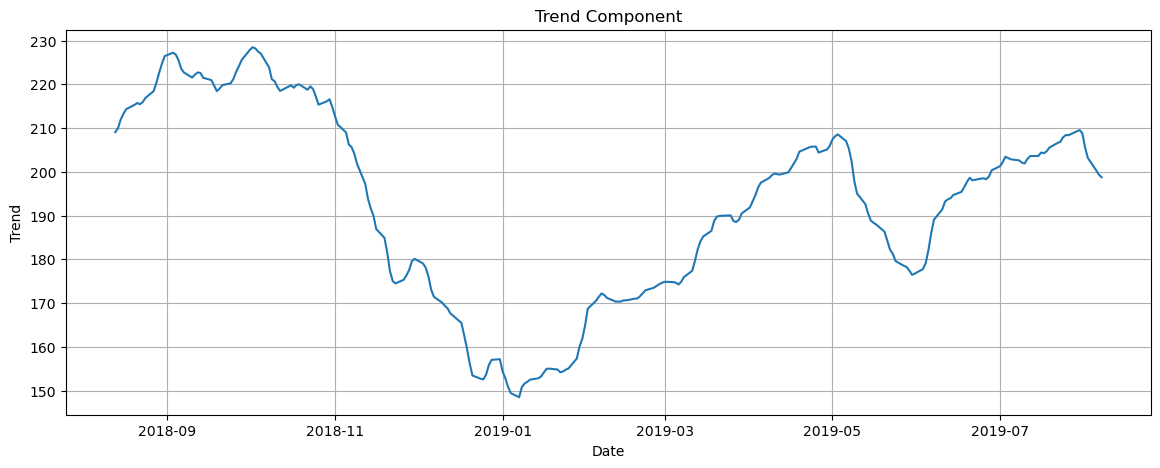

In [137]:
plt.figure(figsize=(14, 5))
plt.plot(trend)
plt.title("Trend Component")
plt.xlabel("Date")
plt.ylabel("Trend")
plt.grid(True)
plt.show()

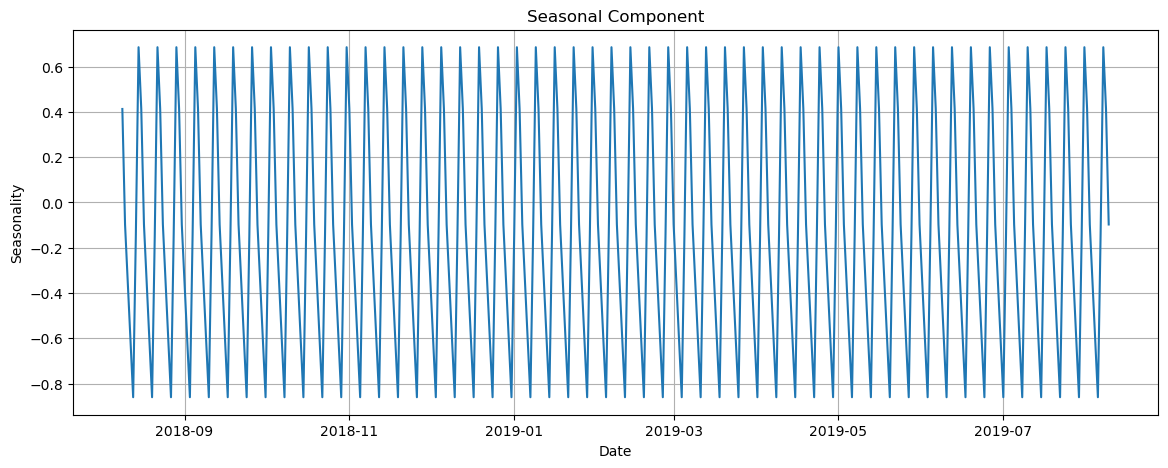

In [138]:
plt.figure(figsize=(14, 5))
plt.plot(seasonal)
plt.title("Seasonal Component")
plt.xlabel("Date")
plt.ylabel("Seasonality")
plt.grid(True)
plt.show()

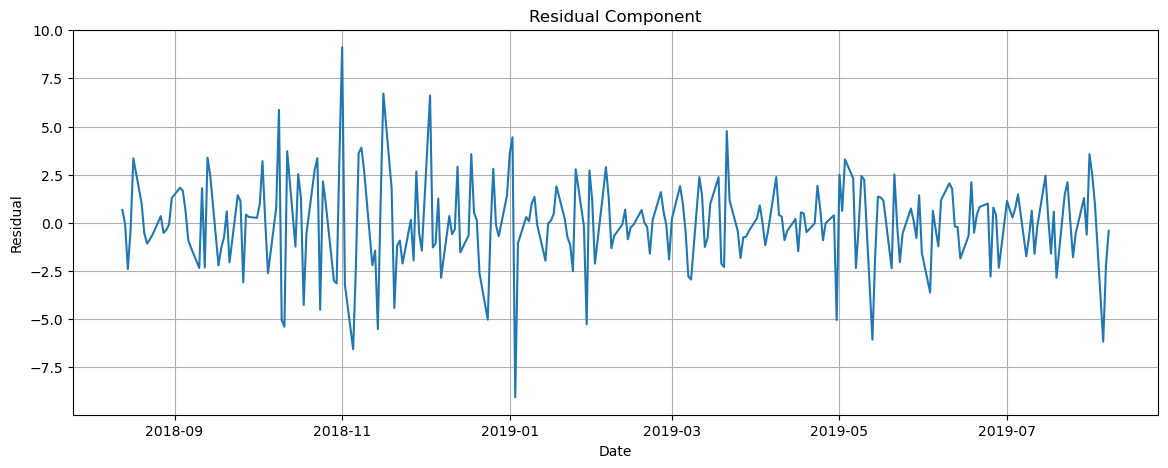

In [139]:
plt.figure(figsize=(14, 5))
plt.plot(residual)
plt.title("Residual Component")
plt.xlabel("Date")
plt.ylabel("Residual")
plt.grid(True)
plt.show()

In [140]:
print("Residual mean:", residual.mean())
print("Residual standard deviation:", residual.std())

Residual mean: -0.005923265460041361
Residual standard deviation: 2.2716303731187084


## Feature Engineering

In [141]:
model_df=df_clean[["close"]].copy()
model_df.head()

,close
date,
2018-08-09,208.88
2018-08-10,207.53
2018-08-13,208.87
2018-08-14,209.75
2018-08-15,210.24


In [142]:
model_df["lag_1"] = model_df["close"].shift(1)
model_df.head()

,close,lag_1
date,,
2018-08-09,208.88,NaN
2018-08-10,207.53,208.88
2018-08-13,208.87,207.53
2018-08-14,209.75,208.87
2018-08-15,210.24,209.75


In [143]:
for lag in [1, 2, 3, 5, 10, 20]:
    model_df[f"lag_{lag}"] = model_df["close"].shift(lag)

In [144]:
model_df.head(25)

,close,lag_1,lag_2,lag_3,lag_5,lag_10,lag_20
date,,,,,,,
2018-08-09,208.88,NaN,NaN,NaN,NaN,NaN,NaN
2018-08-10,207.53,208.88,NaN,NaN,NaN,NaN,NaN
2018-08-13,208.87,207.53,208.88,NaN,NaN,NaN,NaN
2018-08-14,209.75,208.87,207.53,208.88,NaN,NaN,NaN
2018-08-15,210.24,209.75,208.87,207.53,NaN,NaN,NaN
2018-08-16,213.32,210.24,209.75,208.87,208.88,NaN,NaN
2018-08-17,217.58,213.32,210.24,209.75,207.53,NaN,NaN
2018-08-20,215.46,217.58,213.32,210.24,208.87,NaN,NaN
2018-08-21,215.04,215.46,217.58,213.32,209.75,NaN,NaN


In [145]:
model_df["rolling_mean_5"] = (
    model_df["close"]
    .shift(1)
    .rolling(5)
    .mean()
)
model_df["rolling_mean_10"] = (
    model_df["close"]
    .shift(1)
    .rolling(10)
    .mean()
)

model_df["rolling_mean_20"] = (
    model_df["close"]
    .shift(1)
    .rolling(20)
    .mean()
)

In [146]:
model_df["rolling_std_5"] = (
    model_df["close"]
    .shift(1)
    .rolling(5)
    .std()
)

In [147]:
model_df["return_1"] = (
    model_df["close"]
    .pct_change()
    .shift(1)
)

In [148]:
model_df["target"] = model_df["close"]

In [149]:
model_df = model_df.dropna()
model_df.head()

,close,lag_1,lag_2,lag_3,lag_5,lag_10,lag_20,rolling_mean_5,rolling_mean_10,rolling_mean_20,rolling_std_5,return_1,target
date,,,,,,,,,,,,,
2018-09-07,221.30,223.10,226.87,228.36,225.03,215.49,208.88,226.198,222.326,217.249,2.129453,-0.016617,221.30
2018-09-10,218.33,221.30,223.10,226.87,227.63,216.16,207.53,225.452,222.907,217.870,3.081472,-0.008068,218.33
2018-09-11,223.85,218.33,221.30,223.10,228.36,217.94,208.87,223.592,223.124,218.410,4.082373,-0.013421,223.85
2018-09-12,221.07,223.85,218.33,221.30,226.87,219.70,209.75,222.690,223.715,219.159,3.159422,0.025283,221.07
2018-09-13,226.41,221.07,223.85,218.33,223.10,222.98,210.24,221.530,223.852,219.725,2.141950,-0.012419,226.41


In [150]:
feature_cols = [
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_5",
    "lag_10",
    "lag_20",
    "rolling_mean_5",
    "rolling_mean_10",
    "rolling_mean_20",
    "rolling_std_5",
    "return_1"
]
X = model_df[feature_cols]
y = model_df["target"]

In [151]:
X.head()

,lag_1,lag_2,lag_3,lag_5,lag_10,lag_20,rolling_mean_5,rolling_mean_10,rolling_mean_20,rolling_std_5,return_1
date,,,,,,,,,,,
2018-09-07,223.10,226.87,228.36,225.03,215.49,208.88,226.198,222.326,217.249,2.129453,-0.016617
2018-09-10,221.30,223.10,226.87,227.63,216.16,207.53,225.452,222.907,217.870,3.081472,-0.008068
2018-09-11,218.33,221.30,223.10,228.36,217.94,208.87,223.592,223.124,218.410,4.082373,-0.013421
2018-09-12,223.85,218.33,221.30,226.87,219.70,209.75,222.690,223.715,219.159,3.159422,0.025283
2018-09-13,221.07,223.85,218.33,223.10,222.98,210.24,221.530,223.852,219.725,2.141950,-0.012419


In [152]:
y.head()

date
2018-09-07    221.30
2018-09-10    218.33
2018-09-11    223.85
2018-09-12    221.07
2018-09-13    226.41
Name: target, dtype: float64

In [183]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (232, 11)
y shape: (232,)


## Train / Test Split

In [154]:
split_index = int(len(X) * 0.8)
X_train = X.iloc[:split_index].copy()
X_test = X.iloc[split_index:].copy()
y_train = y.iloc[:split_index].copy()
y_test = y.iloc[split_index:].copy()

In [155]:
print("Training data:", len(X_train))
print("Testing data:", len(X_test))
print("\nTraining period:")
print(X_train.index.min().date(), "to", X_train.index.max().date())
print("\nTesting period:")
print(X_test.index.min().date(), "to", X_test.index.max().date())

Training data: 185
Testing data: 47

Training period:
2018-09-07 to 2019-06-04

Testing period:
2019-06-05 to 2019-08-09


## Feature Engg

In [156]:
scaler=StandardScaler()

In [157]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Random Forest Regression

In [158]:
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    max_depth=10
)

In [159]:
model.fit(X_train_scaled, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [160]:
y_pred = model.predict(X_test_scaled)
print(y_pred[:10])

[180.29603708 181.11096667 183.25205    188.69499003 189.27494008
 191.76835625 190.78612792 193.70546667 191.65679167 194.26701667]


In [161]:
results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})
results.head(10)

,Actual,Predicted
0,182.54,180.296037
1,185.22,181.110967
2,190.15,183.252050
3,192.58,188.694990
4,194.81,189.274940
5,194.19,191.768356
6,194.15,190.786128
7,192.74,193.705467
8,193.89,191.656792
9,198.45,194.267017


In [162]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 2.8059683965413673
MSE : 12.387357978435608
RMSE: 3.5195678681388727
R²  : 0.6868660694630628


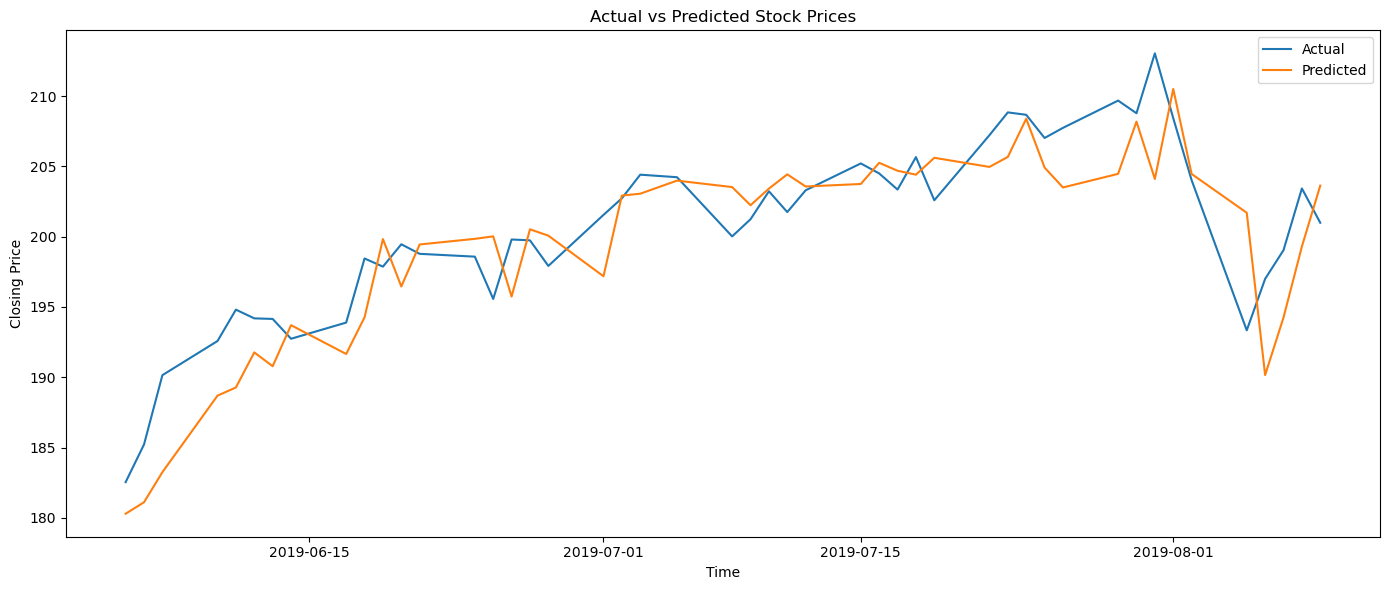

In [163]:
plt.figure(figsize=(14, 6))

plt.plot(y_test.index, y_test.values, label='Actual')
plt.plot(y_test.index, y_pred, label='Predicted')

plt.title('Actual vs Predicted Stock Prices')
plt.xlabel('Time')
plt.ylabel('Closing Price')

plt.legend()
plt.tight_layout()
plt.show()

## Ridge Regression

In [164]:
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_train)
print("Ridge Regression model trained successfully.")

Ridge Regression model trained successfully.


In [165]:
ridge_pred = ridge_model.predict(X_test_scaled)

print("Ridge predictions generated successfully.")

Ridge predictions generated successfully.


In [166]:
ridge_mae = mean_absolute_error(y_test, ridge_pred)
ridge_mse = mean_squared_error(y_test, ridge_pred)
ridge_rmse = np.sqrt(ridge_mse)
ridge_r2 = r2_score(y_test, ridge_pred)

print("Ridge Regression Results")
print("MAE :", ridge_mae)
print("MSE :", ridge_mse)
print("RMSE:", ridge_rmse)
print("R²  :", ridge_r2)

Ridge Regression Results
MAE : 2.4535721197212363
MSE : 10.94926280581794
RMSE: 3.3089670300288487
R²  : 0.7232189701116025


In [167]:
# Compare Random Forest and Ridge Regression

comparison = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R²'],
    'Random Forest': [mae, rmse, r2],
    'Ridge Regression': [ridge_mae, ridge_rmse, ridge_r2]
})

comparison

,Metric,Random Forest,Ridge Regression
0,MAE,2.805968,2.453572
1,RMSE,3.519568,3.308967
2,R²,0.686866,0.723219


In [168]:
# Mean Absolute Percentage Error (MAPE)
rf_mape = np.mean(
    np.abs((y_test.values - y_pred) / y_test.values)
) * 100

print("Random Forest MAPE:", rf_mape)

Random Forest MAPE: 1.4072254559072996


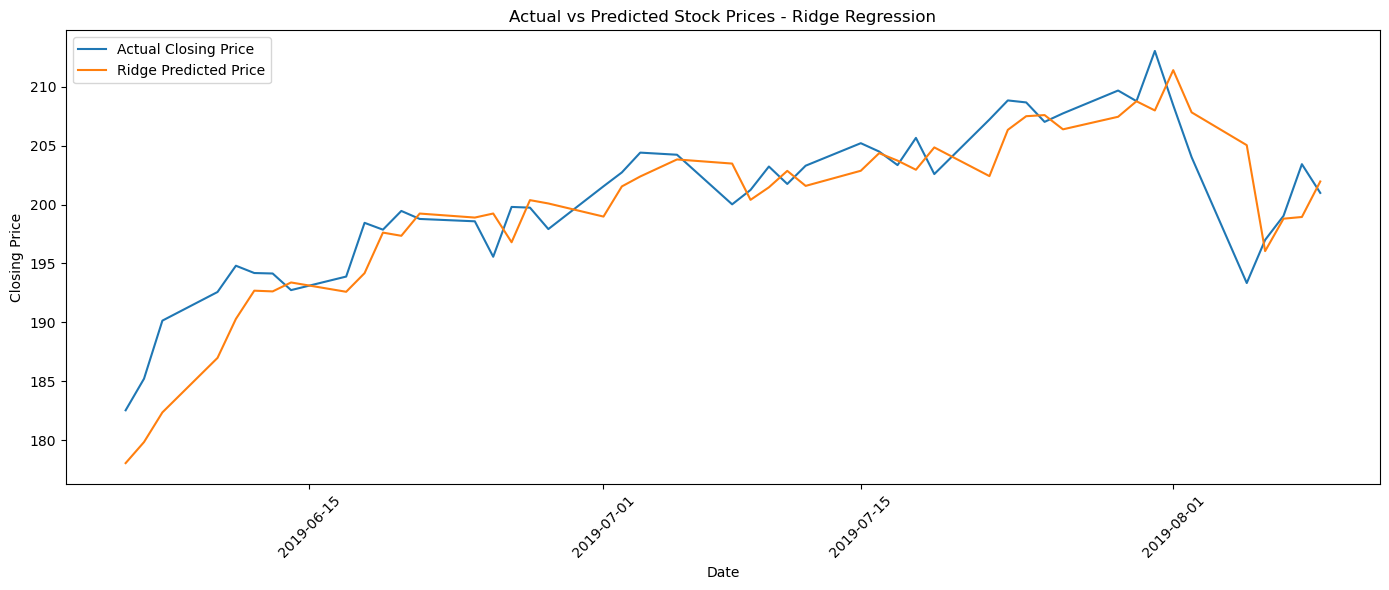

In [169]:
# Actual vs Predicted Closing Prices - Ridge Regression

plt.figure(figsize=(14, 6))

plt.plot(y_test.index, y_test.values, label='Actual Closing Price')
plt.plot(y_test.index, ridge_pred, label='Ridge Predicted Price')

plt.title('Actual vs Predicted Stock Prices - Ridge Regression')
plt.xlabel('Date')
plt.ylabel('Closing Price')

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [170]:
# prediction errors

residuals = y_test.values - ridge_pred

print("Mean Residual:", residuals.mean())
print("Maximum Error:", residuals.max())
print("Minimum Error:", residuals.min())

Mean Residual: 0.9575793751191117
Maximum Error: 7.789361116779787
Minimum Error: -11.702023013677348


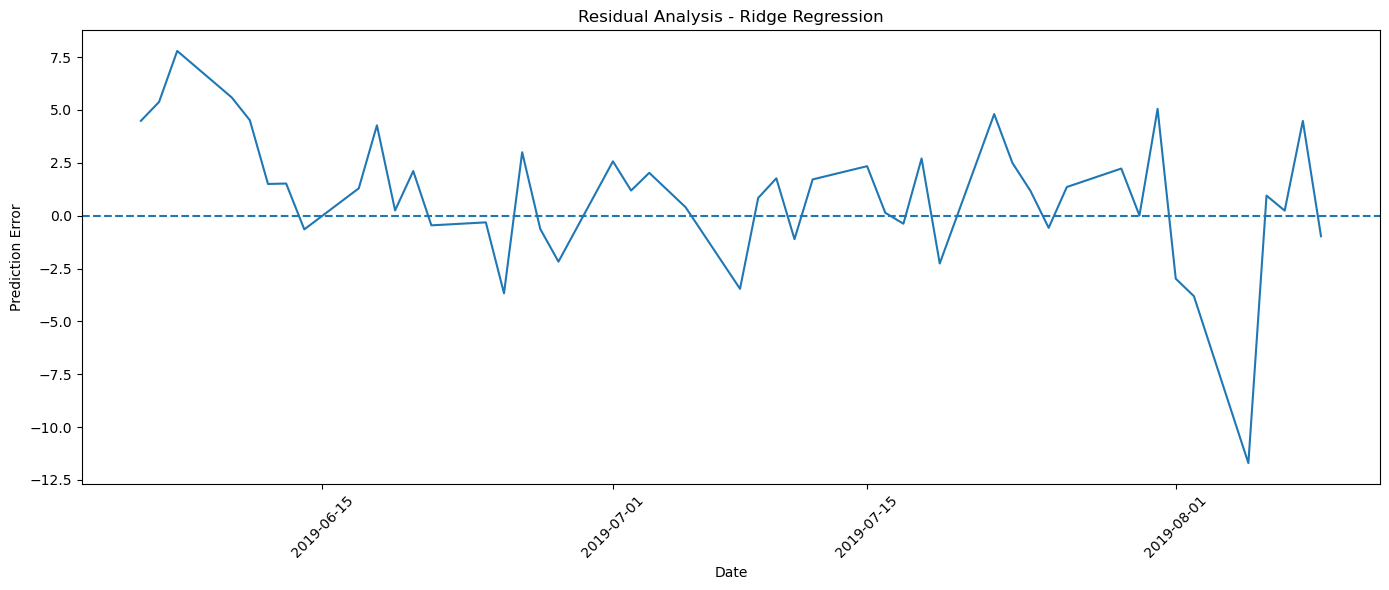

In [171]:
plt.figure(figsize=(14, 6))

plt.plot(y_test.index, residuals)

plt.axhline(y=0, linestyle='--')

plt.title('Residual Analysis - Ridge Regression')
plt.xlabel('Date')
plt.ylabel('Prediction Error')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [172]:
# Ridge Regression coefficients

coefficients = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': ridge_model.coef_
})

coefficients['Absolute_Coefficient'] = coefficients['Coefficient'].abs()

coefficients = coefficients.sort_values(
    by='Absolute_Coefficient',
    ascending=False
)

coefficients

,Feature,Coefficient,Absolute_Coefficient
0,lag_1,9.291488,9.291488
1,lag_2,7.463310,7.463310
6,rolling_mean_5,3.978418,3.978418
10,return_1,1.596189,1.596189
7,rolling_mean_10,1.449154,1.449154
5,lag_20,-1.440088,1.440088
2,lag_3,1.232912,1.232912
3,lag_5,0.908256,0.908256
8,rolling_mean_20,-0.401993,0.401993
4,lag_10,-0.075379,0.075379


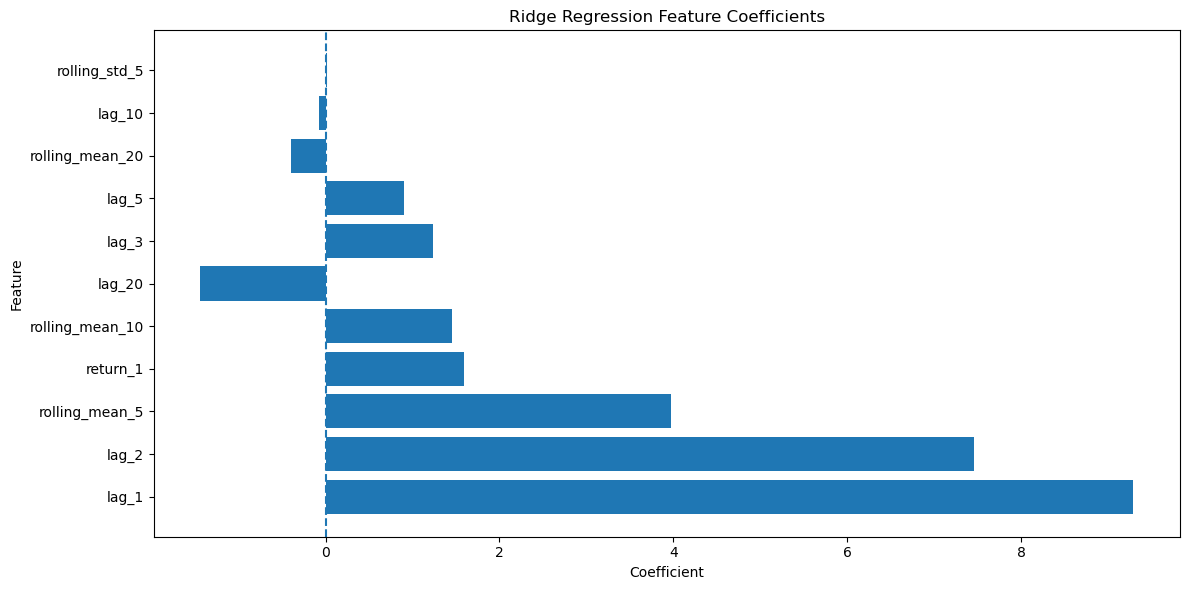

In [173]:
# Plot Ridge Regression feature coefficients

plt.figure(figsize=(12, 6))

plt.barh(
    coefficients['Feature'],
    coefficients['Coefficient']
)

plt.axvline(x=0, linestyle='--')

plt.title('Ridge Regression Feature Coefficients')
plt.xlabel('Coefficient')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()

In [174]:
# Saving the final Ridge Regression model and scaler
joblib.dump(ridge_model, 'ridge_stock_model.pkl')
joblib.dump(scaler, 'stock_feature_scaler.pkl')

print("Final Ridge model and scaler saved successfully.")

Final Ridge model and scaler saved successfully.


In [ ]:
# MAPE for Ridge Regression
ridge_mape = np.mean(
    np.abs((y_test.values - ridge_pred) / y_test.values)
) * 100

print("Ridge MAPE:", ridge_mape)

## Next Day closing price prediction

In [176]:
latest_features = model_df[feature_cols].iloc[[-1]]

print("Latest feature values:")
latest_features

Latest feature values:


,lag_1,lag_2,lag_3,lag_5,lag_10,lag_20,rolling_mean_5,rolling_mean_10,rolling_mean_20,rolling_std_5,return_1
date,,,,,,,,,,,
2019-08-09,203.43,199.04,197.0,204.02,207.74,203.3,199.366,204.45,205.043,4.477519,0.022056


In [177]:
# Scale the latest feature values using the same scaler
latest_features_scaled = scaler.transform(latest_features)
print("Latest features scaled successfully.")

Latest features scaled successfully.


In [178]:
# Predict the next closing price

next_price = ridge_model.predict(latest_features_scaled)[0]

print("Latest Actual Closing Price:", model_df['close'].iloc[-1])
print("Predicted Next Closing Price:", next_price)

Latest Actual Closing Price: 200.99
Predicted Next Closing Price: 201.96125200391825


In [179]:
# Calculate expected price change

current_price = model_df['close'].iloc[-1]

price_change = next_price - current_price
percentage_change = (price_change / current_price) * 100

print("Current Closing Price :", current_price)
print("Predicted Next Price  :", round(next_price, 2))
print("Expected Change       :", round(price_change, 2))
print("Expected Change (%)   :", round(percentage_change, 2), "%")

Current Closing Price : 200.99
Predicted Next Price  : 201.96
Expected Change       : 0.97
Expected Change (%)   : 0.48 %


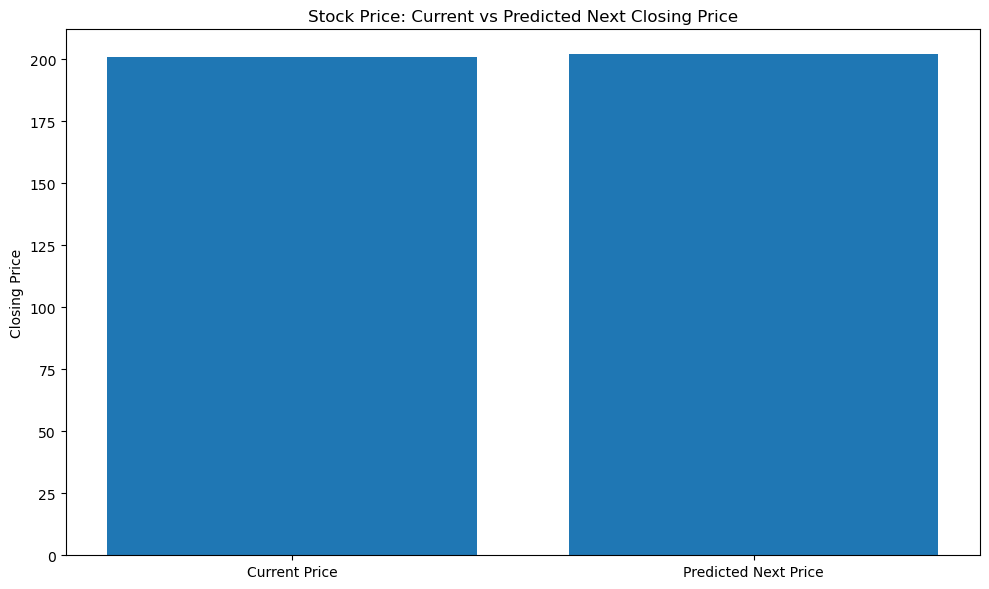

In [180]:
plt.figure(figsize=(10, 6))

plt.bar(
    ['Current Price', 'Predicted Next Price'],
    [current_price, next_price]
)

plt.title('Stock Price: Current vs Predicted Next Closing Price')
plt.ylabel('Closing Price')

plt.tight_layout()
plt.show()

## 7 - Business-Day Future Forecast

In [181]:
# 7-Business-Day Recursive Forecast

forecast_history = df_clean["close"].copy()

forecast_dates = pd.bdate_range(
    forecast_history.index.max() + pd.Timedelta(days=1),
    periods=7
)

future_predictions = []

for forecast_date in forecast_dates:

    temp = forecast_history.copy()

    # Create the same features used while training the Ridge model
    features = {
        "lag_1": temp.iloc[-1],
        "lag_2": temp.iloc[-2],
        "lag_3": temp.iloc[-3],
        "lag_5": temp.iloc[-5],
        "lag_10": temp.iloc[-10],
        "lag_20": temp.iloc[-20],

        "rolling_mean_5": temp.tail(5).mean(),
        "rolling_mean_10": temp.tail(10).mean(),
        "rolling_mean_20": temp.tail(20).mean(),

        "rolling_std_5": temp.tail(5).std(),

        "return_1": temp.iloc[-1] / temp.iloc[-2] - 1
    }

    # Convert features into DataFrame
    X_future = pd.DataFrame([features])

    # Keep exactly the same feature order used during training
    X_future = X_future[feature_cols]

    # Scale using the scaler fitted on training data
    X_future_scaled = scaler.transform(X_future)

    # Predict next closing price
    next_prediction = ridge_model.predict(X_future_scaled)[0]

    future_predictions.append(next_prediction)

    # Add predicted price to history for the next iteration
    forecast_history.loc[forecast_date] = next_prediction


# Create final forecast table
future_forecast = pd.DataFrame({
    "Date": forecast_dates,
    "Forecasted_Close": future_predictions
})

display(future_forecast)

,Date,Forecasted_Close
0,2019-08-12,199.261418
1,2019-08-13,198.588112
2,2019-08-14,198.153728
3,2019-08-15,197.692848
4,2019-08-16,197.159592
5,2019-08-19,196.270331
6,2019-08-20,195.376895


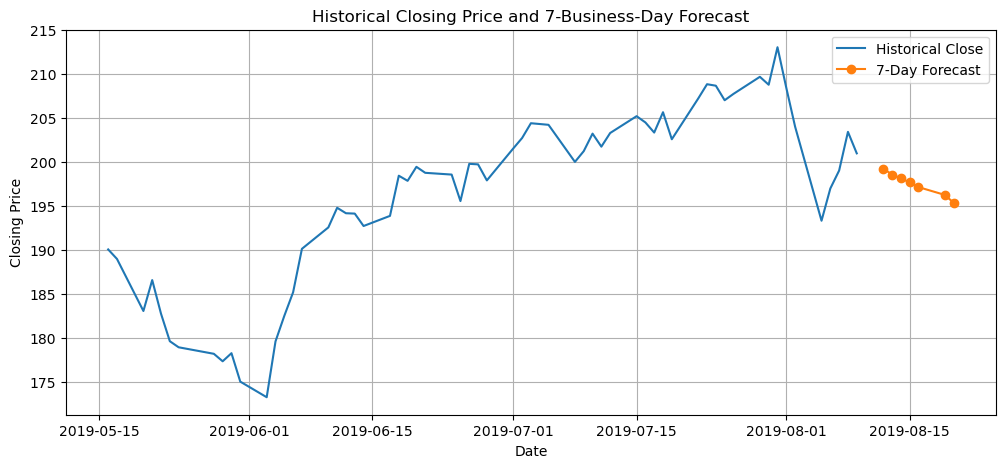

In [182]:
# Visualize the 7-business-day forecast
plt.figure(figsize=(12, 5))

recent_history = df_clean["close"].tail(60)

plt.plot(
    recent_history.index,
    recent_history.values,
    label="Historical Close"
)

plt.plot(
    future_forecast["Date"],
    future_forecast["Forecasted_Close"],
    marker="o",
    label="7-Day Forecast"
)

plt.title("Historical Closing Price and 7-Business-Day Forecast")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend()
plt.grid(True)
plt.show()
